<a href="https://colab.research.google.com/github/iscluisperez85/Inteligencia-Artificial-y-Aprendizaje-Automatico/blob/main/ActividadSemana3_A01840795.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre:** LUIS PEREZ RODRIGUEZ

* **matrícula:** A01840795

------------

* #### **En esta actividad puedes apoyarte en uno o varios Modelos de Lenguaje de Gran Tamaño, LLM por sus siglas en inglés (Large Language Model). Indica claramente cuál o cuáles utilizaste.**

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

Problema de Rotación de Personal en las Organizaciones

El problema de rotación de personal (employee attrition problem) se refiere a la salida de empleados de una organización, ya sea por renuncia, jubilación u otras causas, y a la necesidad de comprender qué factores influyen en estas decisiones. Una rotación elevada puede generar costos importantes relacionados con reclutamiento, capacitación y pérdida de experiencia, además de afectar la productividad y continuidad de los equipos de trabajo, asi como el conocieminto de las herramientas y maquinas que le acompañan. Por ello, analizar datos como antigüedad, salario, satisfacción laboral, carga de trabajo y oportunidades de crecimiento, nivel de estres permite identificar patrones y anticipar posibles riesgos de abandono, facilitando que la empresa implemente estrategias para mejorar la retención del talento.





In [1]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [3]:
path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a) Realiza los análisis descriptivos y/o gráficos que creas adecuados para identificar 4 factores que se deben eliminar desde un inicio.**

**Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



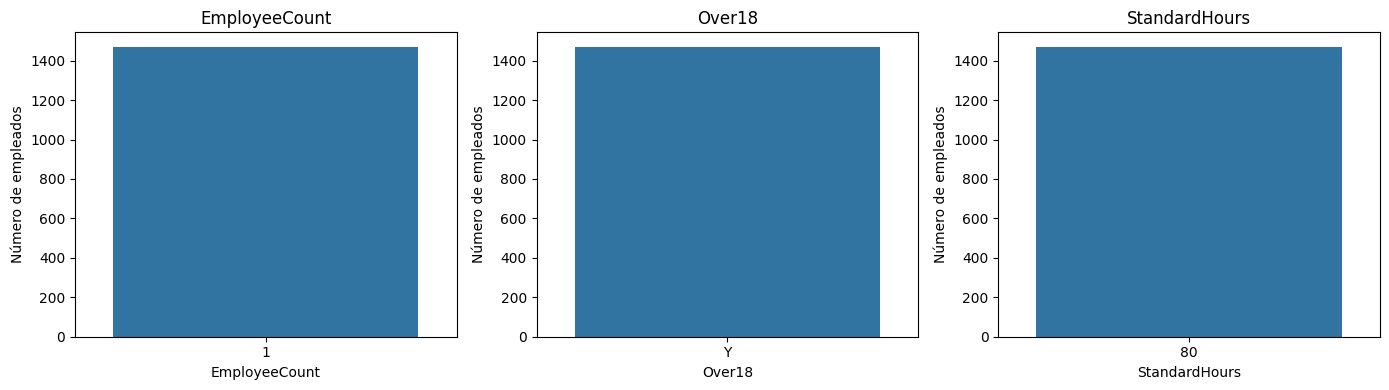

Dimensión original: (1470, 35)
Tamaño del nuevo DataFrame: (1470, 31)


In [6]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.
#Al revisar el archivo, se tienen 1,470 empleados y 35 variables. A partir del análisis descriptivo,
#hay cuatro variables que conviene eliminar antes de continuar: EmployeeCount, Over18, StandardHours y EmployeeNumber.
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

variables = ['EmployeeCount', 'Over18', 'StandardHours']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for var, ax in zip(variables, axes):
    sns.countplot(x=data[var], ax=ax)
    ax.set_title(var)
    ax.set_ylabel("Número de empleados")

plt.tight_layout()
plt.show()


variables_eliminar = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df = data.drop(columns=variables_eliminar)

print("Dimensión original:", data.shape)

# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)

**b) Con base a tu análisis anterior, indica cuáles fueron estas 4 variables y la justificación de por qué se pueden eliminar.**

A partir del análisis descriptivo del conjunto de datos se identificaron cuatro variables que se considera conveniente eliminar antes de realizar análisis posteriores: EmployeeCount, Over18, StandardHours y EmployeeNumber. Las primeras tres no presentan variabilidad, ya que EmployeeCount tiene un valor de 1 para los 1,470 registros, Over18 presenta únicamente la categoría “Y” y StandardHours mantiene un valor constante de 80. Al no existir diferencias entre los empleados, estas variables no aportan información que permita explicar o predecir la rotación de personal. Por otro lado, EmployeeNumber presenta 1,470 valores diferentes para 1,470 empleados, por lo que funciona como un identificador único y no como una característica laboral del trabajador. Mantenerlo podría introducir información sin significado real para el análisis. Por estas razones, se eliminan las cuatro variables y se genera un nuevo DataFrame denominado df, que queda integrado por 1,470 observaciones y 31 variables.

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes como se indica a continuación y en base a la información dada en la plataforma de Kaggle.**

#### **El número entre corcheas indica el número de variables de dicho tipo y el  número entre paréntesis redondos indica el número de niveles.**

* **Variables numéricas [14]:**

   * NumCompaniesWorked

   * TrainingTimesLastYear

   * Age

   * DailyRate

   * DistanceFromHome

   * HourlyRate

   * MonthlyIncome

   * MonthlyRate

   * PercentSalaryHike

   * TotalWorkingYears

   * YearsAtCompany

   * YearsInCurrentRole

   * YearsSinceLastPromotion

   * YearsWithCurrManager

* **Variables ordinales [9]:**

   * Education (5)

   * EnvironmentSatisfaction (4)

   * JobInvolvement (4)

   * JobLevel (5)

   * JobSatisfaction (4)

   * PerformanceRating (2)

   * RelationshipSatisfaction (4)

   * StockOptionLevel (4)

   * WorkLifeBalance (4)

* **Variables binarias [3]:**

   * Attrition (variable de salida)

   * Gender

   * OverTime

* **Variables nominales [5]:**

   * BusinessTravel (3)

   * Department (3)

   * EducationField (6)

   * JobRole (9)

   * MaritalStatus (3)

**Indpendientemente de los factores que al final el modelo identifique como los factores más importantes a considerar en este problema de rotación de personal ¿qué preocupaciones éticas o legales podrían generarse, si algunos de estos factores más importantes a considerar para tomar decisiones sobre los empleados fueran la edad (Age), el género (Gender) o el estado civil (Marital Status)?**


Si variables como la edad (Age), el género (Gender) o el estado civil (Marital Status) resultaran ser factores importantes para predecir la rotación de personal, considero que su utilización para tomar decisiones sobre los empleados podría generar problemas éticos y legales. Aunque estadísticamente estas variables pudieran mostrar alguna relación con la probabilidad de que una persona abandone la empresa, esto no significa que deban utilizarse directamente para decidir sobre contrataciones, promociones, salarios, capacitación o despidos. Hacerlo podría generar prácticas discriminatorias, ya que se estaría evaluando a una persona por características personales y no principalmente por su desempeño, experiencia o capacidades profesionales.

También existe el riesgo de que un modelo de inteligencia artificial aprenda y reproduzca sesgos presentes en los datos históricos. Por ejemplo, si anteriormente existieron diferencias en las oportunidades otorgadas a hombres y mujeres o a trabajadores de determinadas edades, el modelo podría interpretar esos patrones como válidos y continuar reproduciéndolos.

Por ello, considero que estas variables pueden ser útiles para detectar posibles sesgos, estudiar tendencias y evaluar la equidad del modelo, pero deben manejarse con especial cuidado al tomar decisiones individuales. La empresa debe garantizar transparencia, protección de datos personales y supervisión humana. En mi opinión, el hecho de que una variable tenga un alto poder predictivo no significa automáticamente que sea éticamente o legalmente correcto utilizarla para decidir sobre el futuro laboral de una persona, la analítica y la IA deben servir como herramientas de apoyo y no sustituir el pensamiento critico del ser humano ni los principios de igualdad y no discriminación.


# **Ejercicio 4:**

**a) Aunque este problema como está planteado es un problema de clasificación binaria, ¿qué otros enfoques analíticos podrían plantearse y modelarse a partir de este problema? Menciona al menos dos más.**



Aunque el problema de Employee Attrition está planteado como una clasificación binaria para predecir si un empleado dejará o no la organización, considero que los mismos datos pueden utilizarse para desarrollar otros enfoques analíticos.

Un primer enfoque sería realizar un análisis de segmentación o clustering, utilizando técnicas de aprendizaje no supervisado para identificar grupos de empleados con características similares. Por ejemplo, podrían encontrarse perfiles relacionados con antigüedad, nivel de ingresos, satisfacción laboral, horas extra o equilibrio entre vida y trabajo. Posteriormente, se podría analizar qué grupos presentan una mayor proporción de rotación y diseñar estrategias de retención específicas para cada perfil o area.

Un segundo enfoque sería desarrollar un modelo de regresión, cambiando la variable objetivo. Por ejemplo, se podría intentar predecir el MonthlyIncome de los empleados utilizando variables como edad, experiencia, nivel de puesto, educación y años dentro de la empresa. Esto permitiría analizar qué factores están relacionados con las diferencias salariales e incluso detectar posibles inconsistencias.

Adicionalmente, si se contara con información sobre la fecha en que cada empleado abandona la organización, sería posible realizar un análisis de supervivencia, cuyo objetivo no sería únicamente determinar si un empleado dejará la empresa, sino estimar cuánto tiempo podría permanecer en ella y cómo diferentes factores modifican el riesgo de salida a lo largo del tiempo.

Por lo tanto, una misma base de datos puede generar diferentes perspectivas dependiendo de la pregunta y el enfoque que negocio plantie para que se analice y ser respondido con la mayor claridad y asi poder atacar el problema planteado por la empresa.

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [7]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [11]:
# a)
# Crear el codificador
le = LabelEncoder()

# Ajustar SOLO con los datos de entrenamiento
# y transformar ytrain
ytrainT = le.fit_transform(ytrain.values.ravel())

# Aplicar la transformacion aprendida a validacion y prueba
yvalT = le.transform(yval.values.ravel())
ytestT = le.transform(ytest.values.ravel())

# Verificar las clases y su codificacion
print("Clases:", le.classes_)
print("ytrainT:", ytrainT[:10])
print("yvalT:", yvalT[:10])
print("ytestT:", ytestT[:10])

# Corregido: Convertimos ytrainT (que es un numpy array) a una Serie de Pandas para poder calcular las frecuencias con value_counts()
print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', pd.Series(ytrainT).value_counts() / ytrainT.shape[0])

Clases: ['No' 'Yes']
ytrainT: [0 1 0 0 0 0 0 0 0 0]
yvalT: [0 0 0 0 0 1 1 0 0 0]
ytestT: [0 0 0 0 0 0 0 0 1 0]
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la información obtenida y considerando la métrica de la exactitud (accuracy) ¿cuál será el valor del umbral del modelo base o ingenuo (baseline, naive) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**

**e) Indica si el desbalanceo de clases obtenido puede ya considerarse como un problema, y de considerarlo así, qué otra métrica o métricas podrían ser más adecuadas que la exactitud (accuracy).**





**b) **De acuerdo con la documentación de Scikit-learn, LabelEncoder() está diseñado para transformar las etiquetas de la variable objetivo (y) y no las variables predictoras (X). Su función es convertir las clases de la variable de salida en valores numéricos entre 0 y n_classes - 1. En nuestro problema resulta adecuado aplicarlo a Attrition, ya que es la variable objetivo categórica binaria con las clases No y Yes. Para las variables categóricas de entrada existen otras alternativas como OneHotEncoder u OrdinalEncoder, dependiendo de su naturaleza.

**c)** En el contexto del problema de rotación de personal, después de aplicar LabelEncoder(), el valor 0 representa No, es decir, empleados que permanecieron en la organización, mientras que 1 representa Yes, correspondiente a empleados que abandonaron la empresa. Por lo tanto, el objetivo del modelo será identificar, a partir de las características disponibles, qué empleados presentan características asociadas con la clase de rotación (Attrition = 1).

**d)**Al analizar la distribución de Attrition en el conjunto de datos completo se obtienen 1,233 empleados con No y 237 con Yes, de un total de 1,470 empleados. Esto representa aproximadamente:

No = 83.88%

Yes = 16.12%

Un modelo ingenuo que predijera siempre que un empleado no abandonará la empresa (Attrition = 0) tendría:

Accuracy baseline = 1233 / 1470 = 0.8388 ≈ 83.88%

Por lo tanto, un modelo predictivo debería superar aproximadamente el 83.88% de accuracy para mejorar al modelo ingenuo bajo esta métrica. Sin embargo, superar este porcentaje por sí solo no garantiza que tengamos un buen modelo, porque podría obtener una exactitud elevada y aun así identificar muy pocos empleados que realmente abandonan la organización.

**e)** Sí, considero que existe un desbalance relevante, debido a que aproximadamente el 84% de los empleados pertenece a la clase No y solamente el 16% a Yes. Esto puede provocar que un modelo favorezca la predicción de la clase mayoritaria y alcance un accuracy aparentemente alto sin detectar adecuadamente los casos de rotación, que precisamente son los de mayor interés para este problema.

Por esta razón, además del accuracy, sería conveniente considerar métricas como Recall, Precision, F1-score o ROC-AUC. En particular, prestaría atención al Recall de la clase Yes, porque indica qué proporción de los empleados que realmente abandonaron la organización fue identificada correctamente por el modelo. También utilizaría F1-score, ya que permite encontrar un equilibrio entre Precision y Recall. De esta manera, la evaluación no dependería únicamente del elevado porcentaje de empleados que permanecen en la organización.


# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Para la empresa de IBM ¿qué es más costoso? ¿clasificar erróneamente a un empleado que sí renunciará, o por el contrario, generar una falsa alarma?**


,count,mean,std,min,25%,50%,75%,max
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.00,9.0
TrainingTimesLastYear,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.00,6.0
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.0,14235.5,20461.50,26999.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.00,25.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.00,40.0


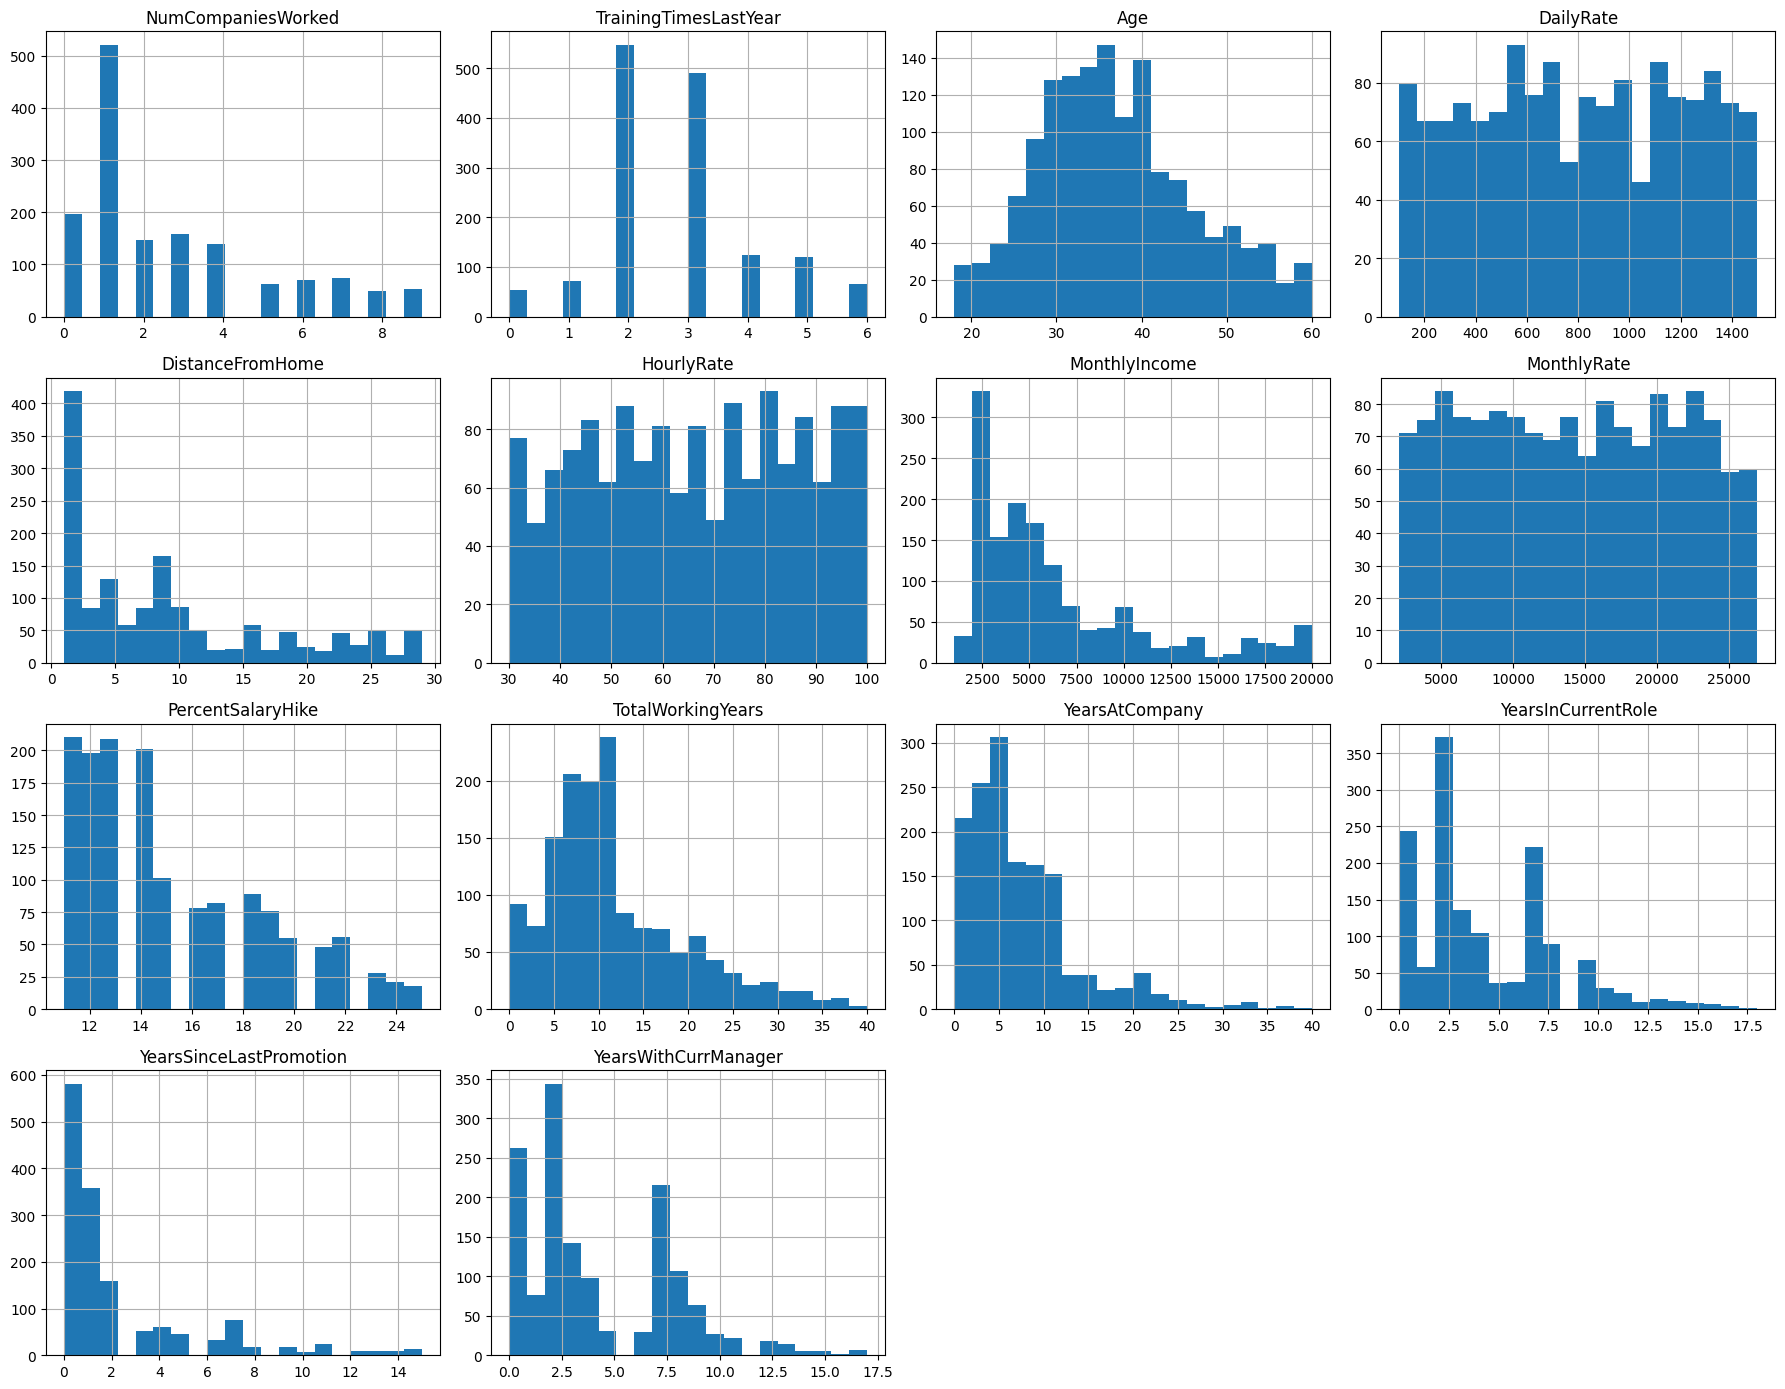

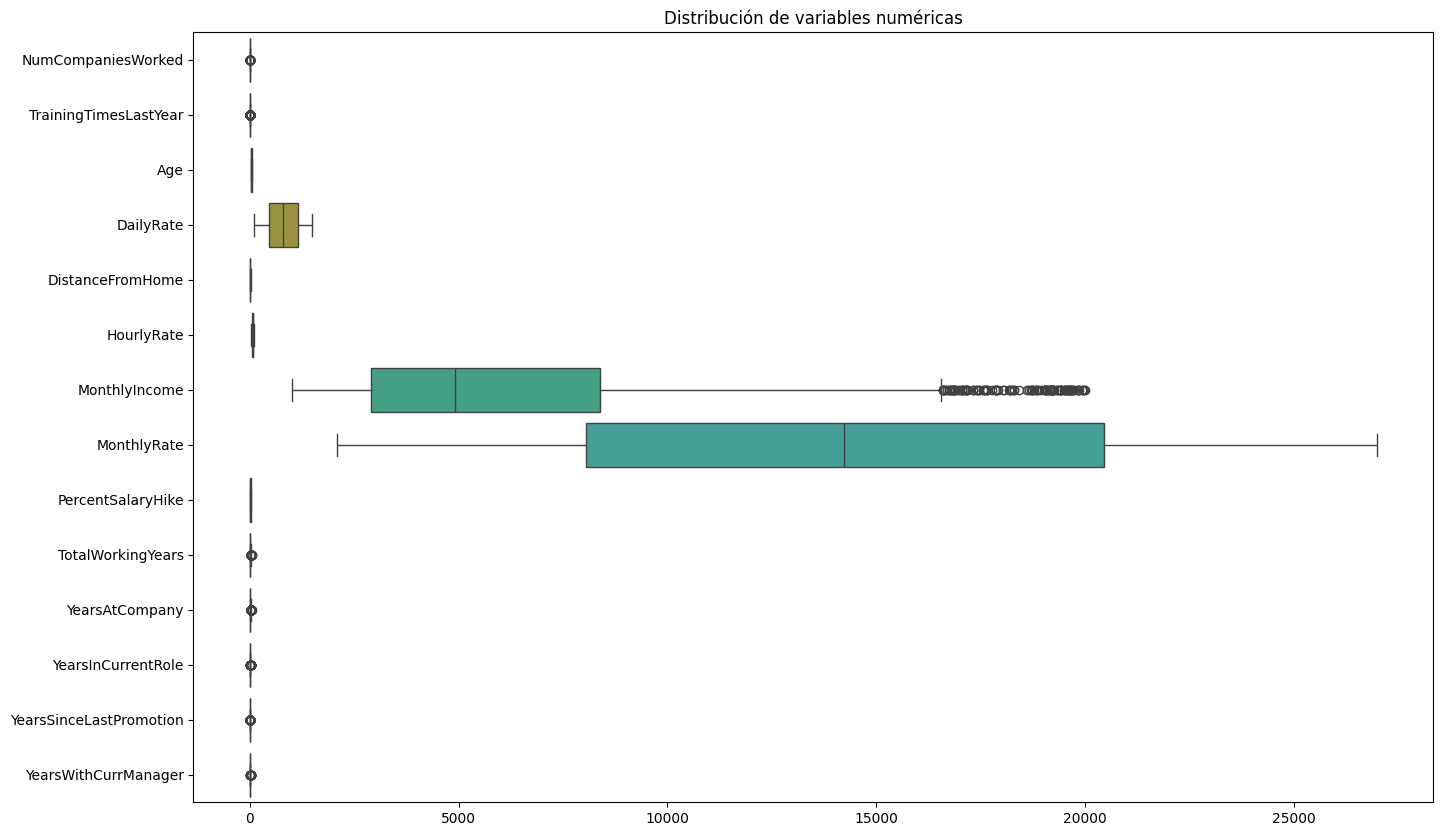

,0
YearsSinceLastPromotion,1.984290
YearsAtCompany,1.764529
MonthlyIncome,1.369817
TotalWorkingYears,1.117172
NumCompaniesWorked,1.026471
DistanceFromHome,0.958118
YearsInCurrentRole,0.917363
YearsWithCurrManager,0.833451
PercentSalaryHike,0.821128
TrainingTimesLastYear,0.553124


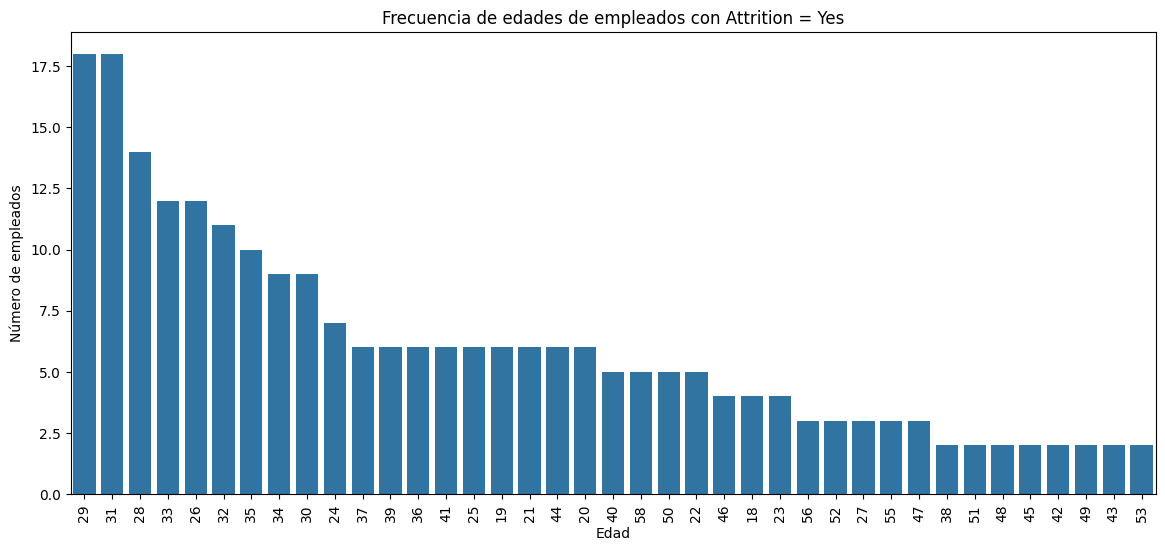

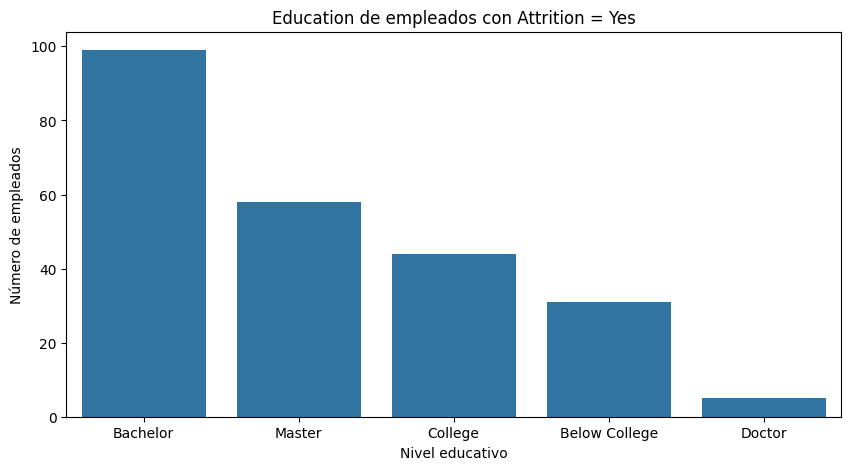

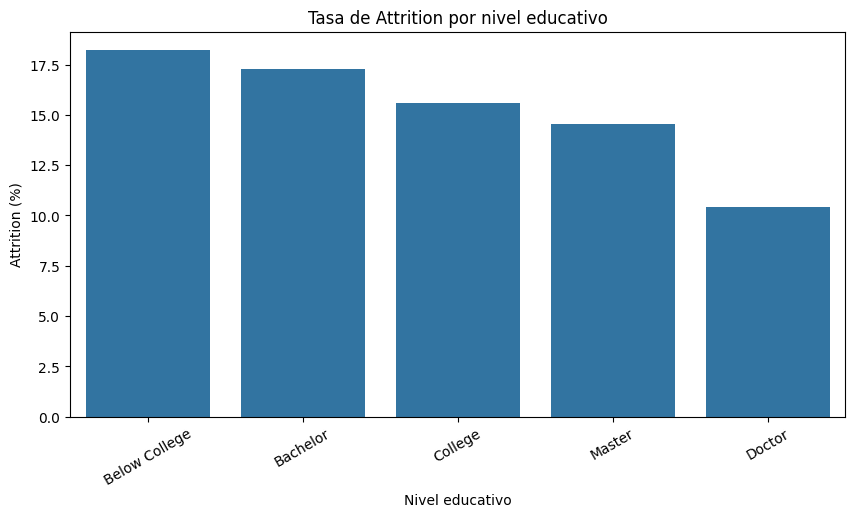

In [15]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos
numeric_cols = [
    'NumCompaniesWorked', 'TrainingTimesLastYear', 'Age',
    'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# Estadística descriptiva
display(df[numeric_cols].describe().T)

# Histogramas
df[numeric_cols].hist(figsize=(18, 14), bins=20)
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(16, 10))
sns.boxplot(data=df[numeric_cols], orient='h')
plt.title("Distribución de variables numéricas")
plt.show()

# Asimetría
display(df[numeric_cols].skew().sort_values(ascending=False))


# b) Gráfico age-attrition[yes]

age_yes = (
    df[df['Attrition'] == 'Yes']['Age']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
sns.barplot(x=age_yes.index.astype(str),
            y=age_yes.values,
            order=age_yes.index.astype(str))

plt.title("Frecuencia de edades de empleados con Attrition = Yes")
plt.xlabel("Edad")
plt.ylabel("Número de empleados")
plt.xticks(rotation=90)
plt.show()

# c) Gráfico education-attrition[yes]
education_labels = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}

education_yes = (
    df[df['Attrition'] == 'Yes']['Education']
    .map(education_labels)
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=education_yes.index, y=education_yes.values)

plt.title("Education de empleados con Attrition = Yes")
plt.xlabel("Nivel educativo")
plt.ylabel("Número de empleados")

# d) [gráfico opcional]

education_rate = (
    df.assign(
        EducationLabel=df['Education'].map(education_labels),
        AttritionYes=(df['Attrition'] == 'Yes').astype(int)
    )
    .groupby('EducationLabel', observed=False)['AttritionYes']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=education_rate.index, y=education_rate.values)

plt.title("Tasa de Attrition por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Attrition (%)")
plt.xticks(rotation=30)
plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**e) ¿Qué es más costoso, los Falsos Negativos o los Falsos Positivos?**

Considero que desde la perspectiva de la empresa, es potencialmente más costoso un falso negativo, es decir, clasificar a un empleado como alguien que permanecerá cuando en realidad terminará renunciando. Este error impediría actuar preventivamente y podría implicar pérdida de conocimiento, costos de contratación y capacitación de un reemplazo. Una falsa alarma también genera costos, pero permitiría revisar la situación del empleado antes de tomar alguna medida. Por esta razón, además del accuracy, considero especialmente importante evaluar el Recall de la clase Attrition=Yes, sin ignorar Precision y F1-score para evitar generar una cantidad excesiva de falsas alarmas.



# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo considerado previamente.**



In [19]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler
)

# NUMÉRICAS:
numeric_cols = [
    'NumCompaniesWorked',
    'TrainingTimesLastYear',
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(
        method='yeo-johnson',
        standardize=True
    ))
])
standardize=True
numericas_pipeline = Pipeline( None )
numericas_pipeline_nombres = None

# ORDINALES:
ordinal_cols = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'WorkLifeBalance'
]
ordinal_categories = [
    [1, 2, 3, 4, 5],   # Education
    [1, 2, 3, 4],      # EnvironmentSatisfaction
    [1, 2, 3, 4],      # JobInvolvement
    [1, 2, 3, 4, 5],   # JobLevel
    [1, 2, 3, 4],      # JobSatisfaction
    [3, 4],            # PerformanceRating
    [1, 2, 3, 4],      # RelationshipSatisfaction
    [0, 1, 2, 3],      # StockOptionLevel
    [1, 2, 3, 4]       # WorkLifeBalance
]

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('ordinal', OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
catOrd_pipeline = Pipeline( None )
catOrd_pipeline_nombres = None

# BINARIAS:
binary_cols = [
    'Gender',
    'OverTime'
]
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(
        drop='if_binary',
        handle_unknown='ignore',
        sparse_output=False
    ))
])
catBin_pipeline = Pipeline( None )
catBin_pipeline_nombres = None

# NOMINALES:
nominal_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'
]
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])
handle_unknown='ignore'
catNom_pipeline = Pipeline( None )
catNom_pipeline_nombres = None


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('bin', binary_pipeline, binary_cols),
        ('nom', nominal_pipeline, nominal_cols)
    ],
    remainder='drop'
)
pipeline_transform = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

columnasTransformer = ColumnTransformer( None )



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [23]:
Xtrain
Xval
Xtest

XtrainT = pipeline_transform.fit_transform(Xtrain)

XvalT = pipeline_transform.transform(Xval)

XtestT = pipeline_transform.transform(Xtest)

print("Xtrain original:", Xtrain.shape)
print("Xtrain transformado:", XtrainT.shape)

print("Xval original:", Xval.shape)
print("Xval transformado:", XvalT.shape)

print("Xtest original:", Xtest.shape)
print("Xtest transformado:", XtestT.shape)
feature_names = pipeline_transform[
    'preprocessor'
].get_feature_names_out()

print(feature_names)

Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = np.concatenate([ytrainT, yvalT], axis=0)

print("Dimension del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Xtrain original: (1029, 30)
Xtrain transformado: (1029, 49)
Xval original: (220, 30)
Xval transformado: (220, 49)
Xtest original: (221, 30)
Xtest transformado: (221, 49)
['num__NumCompaniesWorked' 'num__TrainingTimesLastYear' 'num__Age'
 'num__DailyRate' 'num__DistanceFromHome' 'num__HourlyRate'
 'num__MonthlyIncome' 'num__MonthlyRate' 'num__PercentSalaryHike'
 'num__TotalWorkingYears' 'num__YearsAtCompany' 'num__YearsInCurrentRole'
 'num__YearsSinceLastPromotion' 'num__YearsWithCurrManager'
 'ord__Education' 'ord__EnvironmentSatisfaction' 'ord__JobInvolvement'
 'ord__JobLevel' 'ord__JobSatisfaction' 'ord__PerformanceRating'
 'ord__RelationshipSatisfaction' 'ord__StockOptionLevel'
 'ord__WorkLifeBalance' 'bin__Gender_Male' 'bin__OverTime_Yes'
 'nom__BusinessTravel_Non-Travel' 'nom__BusinessTravel_Travel_Frequently'
 'nom__BusinessTravel_Travel_Rarely' 'nom__Department_Human Resources'
 'nom__Department_Research & Development' 'nom__Department_Sales'
 'nom__EducationField_Human Resource

# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados con respecto a la métrica de la exactitud (accuracy).**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados, independientemente de la métrica a considerar. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera los problemas y obtener mejores resultados.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold" utilizada en este ejercicio, puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.886 (0.015)
>> LASSO 0.889 (0.014)
>> RIDGE 0.887 (0.014)
>> EN 0.887 (0.014)
>> KNN 0.845 (0.006)


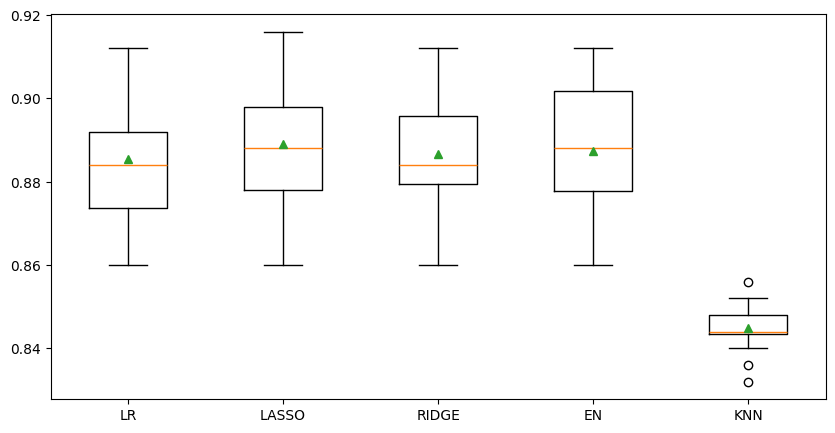

In [27]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás modificarlo.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

def mis_modelos():
    modelos, nombres = list(), list()

    # LR - Regresión Logística sin regularización:
    modelos.append(
        LogisticRegression(
            penalty=None,          # No modificar
            solver='lbfgs',
            max_iter=5000,
            random_state=1
        )
    )
    nombres.append('LR')


    # Lasso - Regresión Logística con regularización L1:
    modelos.append(
        LogisticRegression(
            penalty='l1',
            C=0.5,
            solver='saga',
            max_iter=5000,
            random_state=1
        )
    )
    nombres.append('LASSO')


    # Ridge - Regresión Logística con regularización L2:
    modelos.append(
        LogisticRegression(
            penalty='l2',
            C=1.0,
            solver='lbfgs',
            max_iter=5000,
            random_state=1
        )
    )
    nombres.append('RIDGE')


    # Elastic Net - Regresión Logística con regularización L1 y L2:
    modelos.append(
        LogisticRegression(
            penalty='elasticnet',
            C=1.0,
            l1_ratio=0.5,
            solver='saga',
            max_iter=5000,
            random_state=1
        )
    )
    nombres.append('EN')


    # KNN - K Vecinos más cercanos:
    modelos.append(
        KNeighborsClassifier(
            n_neighbors=7,
            weights='distance',
            metric='minkowski',
            p=2
        )
    )
    nombres.append('KNN')

    return modelos, nombres


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay obviamente varias maneras de llevar a cabo el entrenamiento,
# pero por el momento supongamos que lo hacemos de la manera siguiente:

columnasTransformer = preprocessor

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados con la exactitud (accuracy).


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()

**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo. ¿Alguno quedó subentrenado y ya no se pudo mejorar su desempeño?**

Los resultados obtenidos mediante validación cruzada muestran que todos los modelos lograron superar el accuracy baseline de 83.88%. Los modelos de regresión logística presentaron resultados bastante similares: LR obtuvo 88.6%, LASSO 88.9%, Ridge 88.7% y Elastic Net 88.7%. Por su parte, KNN alcanzó 84.5%.

Considerando únicamente la métrica solicitada de accuracy, considero que LASSO fue el modelo con mejor desempeño, al obtener el mayor promedio con 88.9% y una desviación estándar de 1.4%. Además de presentar el accuracy más alto, su baja variabilidad entre las diferentes particiones indica un comportamiento relativamente estable. Sin embargo, las diferencias entre LASSO, Ridge, Elastic Net y la regresión logística sin regularización son pequeñas, por lo que no se puede afirmar que exista una diferencia considerable entre ellos únicamente con estos resultados.

El modelo que presentó mayores dificultades fue KNN. Aunque alcanzó un accuracy de 84.5%, superando el baseline por aproximadamente 0.62 puntos porcentuales, su mejora es muy reducida en comparación con los demás modelos. Por ello, puede considerarse que KNN presenta un desempeño cercano al subentrenamiento, aun después del ajuste realizado, mientras que los modelos de regresión logística superan claramente el modelo ingenuo.

Finalmente, debido al desbalance de Attrition, considero que no debemos seleccionar definitivamente un modelo basándonos solamente en accuracy. Aunque LASSO es el mejor bajo esta métrica, será necesario revisar Recall, Precision, F1-score y la matriz de confusión, especialmente para Attrition=Yes, ya que el objetivo práctico es identificar correctamente a los empleados con riesgo de abandonar la organización.


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [32]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

pipeline_lasso = Pipeline(steps=[
    ('ct', columnasTransformer),

    ('m', LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=5000,
        random_state=1
    ))
])

param_grid = {
    'm__C': [
        0.001, 0.005, 0.01, 0.02, 0.05,
        0.1, 0.2, 0.5, 1, 2, 5, 10,
        20, 50, 100
    ],

    'm__class_weight': [
        None,
        'balanced'
    ]
}

cv_malla = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=7
)

grid = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv_malla,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(Xtv, np.ravel(ytv))

resultado_malla = grid.best_estimator_

mejor_indice = grid.best_index_

accuracy_train = grid.cv_results_[
    'mean_train_score'
][mejor_indice]

accuracy_validation = grid.cv_results_[
    'mean_test_score'
][mejor_indice]

diferencia = abs(
    accuracy_train - accuracy_validation
)

baseline = 0.8388

print("==========================================")
print("RESULTADOS DE LA BÚSQUEDA DE MALLA")
print("==========================================")

print("\nMejores hiperparámetros:")
print(grid.best_params_)

print("\nAccuracy Train:")
print(round(accuracy_train, 4))

print("\nAccuracy Validation:")
print(round(accuracy_validation, 4))

print("\nDiferencia Train - Validation:")
print(round(diferencia, 4))

print("\nDiferencia porcentual:")
print(round(diferencia * 100, 2), "%")

print("\n==========================================")
print("DIAGNÓSTICO DEL MODELO")
print("==========================================")

if accuracy_validation > baseline:
    print(
        "El modelo supera el baseline de",
        baseline,
        "por lo tanto NO está subentrenado."
    )
else:
    print(
        "El modelo NO supera el baseline de",
        baseline,
        "por lo tanto podría considerarse subentrenado."
    )

if diferencia < 0.03:
    print(
        "La diferencia entre Train y Validation es menor al 3%,",
        "por lo tanto el modelo NO está sobreentrenado."
    )
else:
    print(
        "La diferencia entre Train y Validation es mayor o igual al 3%,",
        "por lo tanto el modelo podría estar sobreentrenado."
    )


resultados_grid = pd.DataFrame(
    grid.cv_results_
)

tabla_resultados = resultados_grid[[
    'param_m__C',
    'param_m__class_weight',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]].sort_values(
    by='rank_test_score'
)

print("\n==========================================")
print("MEJORES COMBINACIONES DE HIPERPARÁMETROS")
print("==========================================")

display(tabla_resultados.head(10))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (grid.best_score_, grid.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(grid.cv_results_['mean_train_score']),
                                                 100*np.nanmean(grid.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*grid.cv_results_['mean_test_score'].mean(),
                                               100*grid.cv_results_['std_test_score'].mean()))

RESULTADOS DE LA BÚSQUEDA DE MALLA

Mejores hiperparámetros:
{'m__C': 0.5, 'm__class_weight': None}

Accuracy Train:
0.905

Accuracy Validation:
0.889

Diferencia Train - Validation:
0.016

Diferencia porcentual:
1.6 %

DIAGNÓSTICO DEL MODELO
El modelo supera el baseline de 0.8388 por lo tanto NO está subentrenado.
La diferencia entre Train y Validation es menor al 3%, por lo tanto el modelo NO está sobreentrenado.

MEJORES COMBINACIONES DE HIPERPARÁMETROS


,param_m__C,param_m__class_weight,mean_train_score,mean_test_score,std_test_score,rank_test_score
14,0.5,None,0.904991,0.888977,0.014363,1
16,1.0,None,0.906459,0.887911,0.015736,2
18,2.0,None,0.907126,0.886840,0.014521,3
22,10.0,None,0.906725,0.885773,0.014244,4
20,5.0,None,0.907192,0.885507,0.014460,5
24,20.0,None,0.906925,0.885505,0.014841,6
26,50.0,None,0.907059,0.884969,0.015186,7
28,100.0,None,0.906992,0.884969,0.015186,7
12,0.2,None,0.894048,0.883641,0.015354,9
10,0.1,None,0.876901,0.870026,0.009381,10


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.888977 usando los hiperparámetros {'m__C': 0.5, 'm__class_weight': None}
Promedios Train mean(std): 81.87% (2.8211%)
Promedios Val mean(std): 80.29% (3.8767%)


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [33]:
# a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.

from sklearn.metrics import classification_report, accuracy_score

y_pred_test = resultado_malla.predict(Xtest)

# Accuracy final
accuracy_test = accuracy_score(ytestT, y_pred_test)

print("Accuracy final en Test:", round(accuracy_test, 4))

print("\nClassification Report:")
print(
    classification_report(
        ytestT,
        y_pred_test,
        target_names=['No', 'Yes'],
        digits=4
    )
)

Accuracy final en Test: 0.8643

Classification Report:
              precision    recall  f1-score   support

          No     0.8856    0.9622    0.9223       185
         Yes     0.6500    0.3611    0.4643        36

    accuracy                         0.8643       221
   macro avg     0.7678    0.6616    0.6933       221
weighted avg     0.8472    0.8643    0.8477       221



Matriz de confusión:
[[178   7]
 [ 23  13]]


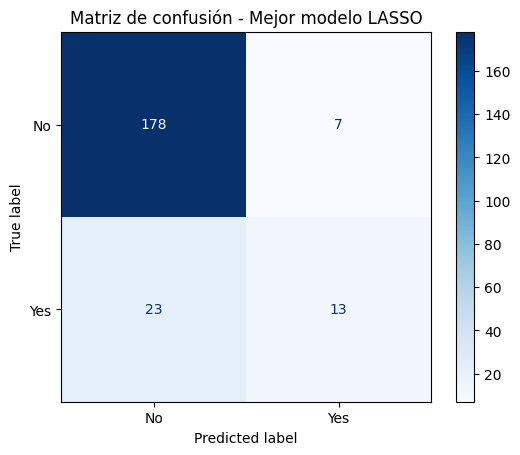

In [34]:
# b) Matriz de confusión:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = resultado_malla.predict(Xtest)

cm = confusion_matrix(ytestT, y_pred_test)

print("Matriz de confusión:")
print(cm)

# Mostrar gráficamente
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No', 'Yes']
)

disp.plot(cmap='Blues')
plt.title("Matriz de confusión - Mejor modelo LASSO")
plt.show()


*  c) Interpretación de VP, VF, FP, FN.

En este problema consideramos como clase positiva Attrition = Yes, es decir, que el empleado abandona la empresa, y como clase negativa Attrition = No, que el empleado permanece.
- VP – Verdadero Positivo: el modelo predice que el empleado renunciará (Yes) y efectivamente el empleado abandona la compañía. Es una predicción correcta que permitiría a la empresa anticiparse y aplicar alguna estrategia de retención.
- VN – Verdadero Negativo: el modelo predice que el empleado permanecerá (No) y efectivamente continúa trabajando en la empresa. También corresponde a una clasificación correcta.
- FP – Falso Positivo: el modelo predice que el empleado renunciará (Yes), pero en realidad permanece en la organización. Se genera una falsa alarma, que podría provocar que la empresa destine innecesariamente recursos o acciones de retención hacia ese empleado.
- FN – Falso Negativo: el modelo predice que el empleado permanecerá (No), pero en realidad termina abandonando la organización. Este error puede ser especialmente importante para la empresa porque el modelo no detectó anticipadamente el riesgo de salida, perdiéndose la oportunidad de implementar acciones de retención, considerando este como el mas costoso para la empresa.

En conclusión, tanto FP como FN representan errores, pero en el contexto planteado un FN podría tener un mayor costo para la empresa, debido a los posibles gastos de reemplazo, reclutamiento, capacitación y pérdida de conocimiento asociados con una renuncia no anticipada. Por esta razón, además del accuracy, resulta especialmente relevante analizar el Recall de la clase Attrition = Yes, ya que permite conocer qué proporción de los empleados que realmente abandonan la empresa está siendo identificada correctamente.

15 características más importantes:


,Variable,Coeficiente,Importancia
24,bin__OverTime_Yes,1.981990,1.981990
26,nom__BusinessTravel_Travel_Frequently,0.957968,0.957968
48,nom__MaritalStatus_Single,0.764099,0.764099
29,nom__Department_Research & Development,-0.665055,0.665055
16,ord__JobInvolvement,-0.623514,0.623514
25,nom__BusinessTravel_Non-Travel,-0.610058,0.610058
36,nom__EducationField_Technical Degree,0.568900,0.568900
6,num__MonthlyIncome,-0.551226,0.551226
39,nom__JobRole_Laboratory Technician,0.517053,0.517053
15,ord__EnvironmentSatisfaction,-0.447058,0.447058


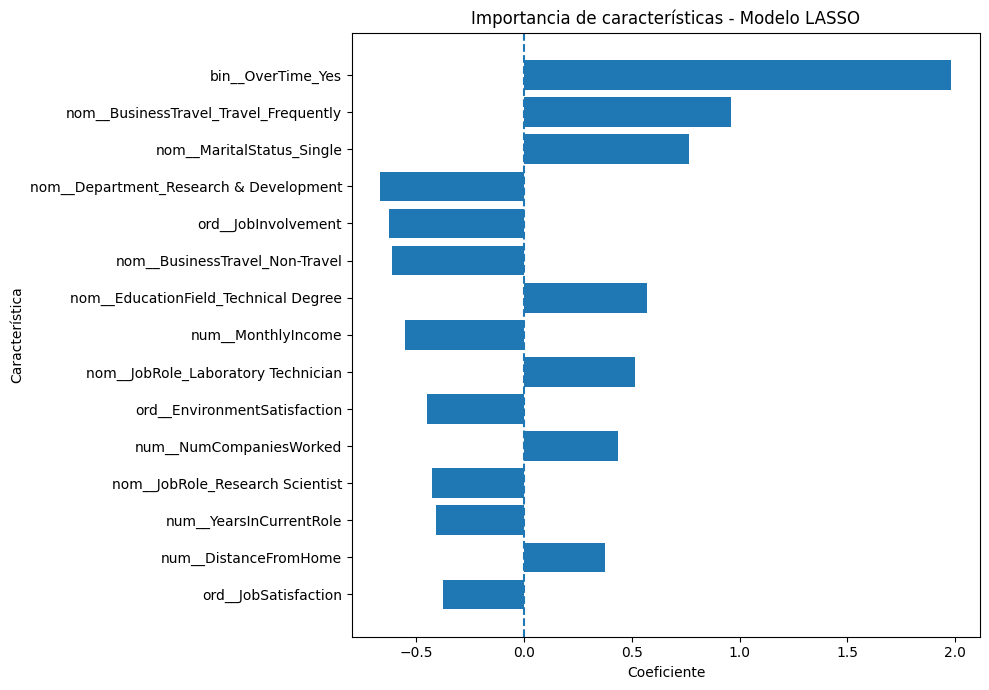

In [35]:
# 10d) Importancia de factores


transformador = resultado_malla.named_steps['ct']
modelo = resultado_malla.named_steps['m']

nombres_variables = transformador.get_feature_names_out()

coeficientes = modelo.coef_[0]

importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia': np.abs(coeficientes)
})

importancia = importancia.sort_values(
    by='Importancia',
    ascending=False
)

print("15 características más importantes:")
display(importancia.head(15))

# Gráfica
top15 = importancia.head(15).sort_values('Importancia')

plt.figure(figsize=(10, 7))
plt.barh(top15['Variable'], top15['Coeficiente'])
plt.axvline(x=0, linestyle='--')
plt.xlabel("Coeficiente")
plt.ylabel("Característica")
plt.title("Importancia de características - Modelo LASSO")
plt.tight_layout()
plt.show()



*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

Este análisis de importancia muestra que la variable con mayor peso en la predicción de la rotación es OverTime_Yes, con un coeficiente positivo de 1.98, lo que indica una asociación fuerte con una mayor probabilidad de que el empleado abandone la organización.

 También destacan BusinessTravel_Travel_Frequently y MaritalStatus_Single, ambas con coeficientes positivos, por lo que el modelo las relaciona con una mayor propensión a Attrition=Yes. De manera similar, aparecen con asociación positiva variables como Technical Degree, Laboratory Technician, NumCompaniesWorked y DistanceFromHome.

Algunas variables muestran coeficientes negativos, lo que en el modelo se asocia con una menor probabilidad de rotación. Entre las más importantes se encuentran Department_Research & Development, JobInvolvement, BusinessTravel_Non-Travel, MonthlyIncome, EnvironmentSatisfaction, Research Scientist, YearsInCurrentRole y JobSatisfaction. Esto sugiere que mayores niveles de involucramiento, satisfacción, permanencia en el puesto e ingreso mensual tienden a estar relacionados con una mayor permanencia en la empresa.
Desde una perspectiva de gestión de Recursos Humanos, considero especialmente relevantes factores como horas extra, frecuencia de viajes, satisfacción laboral, involucramiento, ingreso mensual y distancia al trabajo, ya que pueden ser variables sobre las que la organización tenga cierto margen de acción.

 En cambio, variables como el estado civil deben interpretarse con mayor precaución, ya que aunque tengan importancia predictiva, no necesariamente deben utilizarse para tomar decisiones laborales individuales y finalmente, estos resultados deben entenderse como asociaciones identificadas por el modelo y no como relaciones causales. El hecho de que una variable tenga un coeficiente alto no significa que por sí sola provoque la renuncia del empleado. Sin embargo, sí puede ayudar a identificar patrones relevantes y orientar estrategias de retención más enfocadas.

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quiénes de los colaboradores de la empresa estarán abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) Con base a los resultados de la matriz de confusión, ¿qué tipo de error (FN o FP) está considerando como más costoso el modelo? En particular, ¿coincide con la respuesta que diste en el Ejercicio 6e?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, supongamos que vas a comunicarle tus resultados a los directivos de la empresa o al personal del área de Recursos Humanos.**

* **d) ¿En cuáles ejercicios anteriores consideras que el (o los) modelo de lenguaje de gran tamaño LLM utilizado fue de mayor ayuda? ¿Por qué?**

* **e) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


* a) Considero que la predicción del modelo no debería utilizarse para señalar, sancionar, limitar oportunidades o sustituir la decisión humana sobre un colaborador. Su principal utilidad debería ser preventiva: identificar patrones generales de riesgo y ayudar a Recursos Humanos a diseñar mejores estrategias de retención. Por ejemplo, en nuestros resultados observamos que las horas extra (OverTime), los viajes frecuentes, la satisfacción laboral, el involucramiento y el ingreso mensual tienen una participación importante en las predicciones. Esta información podría orientar acciones generales como revisar cargas de trabajo, políticas de horas extra, esquemas de compensación, condiciones de viaje o programas de desarrollo y satisfacción laboral. Además, el acceso a las predicciones individuales debería estar restringido al personal autorizado, con controles de confidencialidad y protección de datos. Variables personales como el estado civil requieren especial precaución: aunque el modelo las encuentre predictivas, esto no significa que sea apropiado utilizarlas para tomar decisiones laborales y considero que el modelo debe funcionar como herramienta de apoyo a la decisión, no como quien toma la decisión siempre requiere de pensamiento critico basado en la informacion obtenida para tomar una decisión.

* b) En este problema considero que el Falso Negativo (FN) representa el error potencialmente más costoso desde la perspectiva de retención. Un FN ocurre cuando el modelo predice que un empleado permanecerá en la empresa, pero realmente termina abandonándola. En este caso, Recursos Humanos podría no identificar a tiempo una situación de riesgo y perder la oportunidad de analizar las causas o implementar acciones de retención. Esto coincide con lo analizado anteriormente en el ejercicio 6e, donde consideramos importante no depender únicamente del accuracy y prestar atención al Recall de Attrition = Yes, ya que necesitamos conocer qué tan bien detectamos a quienes realmente abandonan la organización, en definitiva debe contrastarse con los valores concretos de FN y FP de la matriz de confusión. Si el modelo produce muchos FN, existe una oportunidad clara de mejorar su capacidad para detectar la clase Yes, aun cuando su accuracy general sea alto.

* c) Para comunicar los resultados evitaría comenzar con conceptos técnicos como regularización L1, hiperparámetros o validación cruzada. En su lugar, explicaría primero qué problema buscamos resolver, qué tan bien funciona el modelo y cómo puede apoyar al negocio. Por ejemplo: desarrollamos una herramienta que analiza información histórica de los empleados para reconocer patrones asociados con la rotación. Posteriormente explicaría su desempeño utilizando porcentajes y la matriz de confusión de manera sencilla: de cada determinado número de empleados que realmente abandonaron la empresa, cuántos logramos identificar correctamente y cuántos no detectamos.


También presentaría visualmente los principales factores encontrados. En nuestro modelo, por ejemplo, las horas extra fueron la característica con mayor importancia, seguidas por los viajes frecuentes y otras características relacionadas con las condiciones personales y laborales. Explicaría también que variables como satisfacción laboral, involucramiento, ingreso mensual y años en el puesto aportan información relevante al modelo. Lo más importante sería aclarar que estas relaciones no prueban causalidad. El mensaje para los directivos sería que el modelo permite identificar patrones y apoyar estrategias preventivas, pero no debería utilizarse de manera automática para decidir sobre contrataciones, despidos, promociones o compensaciones de una persona.

* d) Considero que el LLM fue de mayor ayuda principalmente en las etapas de preprocesamiento, selección y comparación de modelos, búsqueda de hiperparámetros e interpretación de los resultados, la explicacion de como generar lo antes solicitado, la parte de programación me permitió comprender mejor cómo integrar las transformaciones mediante Pipeline y ColumnTransformer, así como utilizar validación cruzada y GridSearchCV sin generar fuga de información entre los conjuntos de entrenamiento y validación. Donde tuvo mayor valor fue en la interpretación o explicacion: no solamente obtener un accuracy, sino entender qué significaban métricas como Precision, Recall, F1-score, los falsos positivos y falsos negativos y los coeficientes obtenidos con LASSO. En la explicacion de como interpretar LASSSO y como utilizarla, apoyo para entender los resultados al ejecutar el código y posteriormente las explicaciones al contexto de rotación de empleados. Esto fue especialmente útil para diferenciar entre que una variable sea importante para realizar una predicción y afirmar incorrectamente que dicha variable sea la causa directa de que un empleado abandone la organización. En general el poder preguntar y pedir explicacion de lo que vas desarrollando en lo personal hace que puedas enteneder e interpretar los resultados.

* e)A lo largo de esta actividad entendí que crear un modelo de aprendizaje automático no se trata solamente de obtener el porcentaje de accuracy más alto. Por ejemplo, desde el inicio vimos que los datos estaban desbalanceados, ya que cerca del 84% de los empleados no abandonaban la empresa. Esto me ayudó a entender que un buen porcentaje de exactitud no siempre significa que el modelo realmente esté haciendo buenas predicciones.
Después de comparar varios modelos, LASSO obtuvo el mejor resultado con aproximadamente 88.9% de accuracy, aunque otros modelos como Regresión Logística, Ridge y Elastic Net tuvieron resultados muy similares. También aprendí que es importante ajustar los parámetros del modelo y posteriormente probarlo con datos que no utilizó durante su entrenamiento.
Algo que me pareció interesante fue conocer cuáles variables tenían mayor importancia para el modelo. La que más destacó fue trabajar horas extra (OverTime), seguida de los viajes frecuentes. También aparecieron factores como la satisfacción laboral, el ingreso, la distancia al trabajo y el tiempo que lleva una persona en su puesto. Sin embargo, entendí que esto no significa que estas variables sean directamente la causa de que una persona renuncie, sino que el modelo encontró una relación entre ellas y la rotación.
Como conclusión, esta actividad me permitió entender mejor cómo un modelo de aprendizaje automático puede servir como una herramienta de apoyo para tomar decisiones, pero no debe sustituir el criterio de las personas. En un tema tan sensible como Recursos Humanos, considero importante combinar los resultados del modelo con la experiencia del área, cuidar la privacidad de los empleados y utilizar la información de manera ética.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de Rotación de Personal de la Semana 3** <<